**Import Data and Required Packages**

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

In [18]:
import dagshub
dagshub.init(repo_owner='aditya-mahato-8924', repo_name='Placement-Predictor', mlflow=True)

Initialized MLflow to track repo "aditya-mahato-8924/Placement-Predictor"

Repository aditya-mahato-8924/Placement-Predictor initialized!

In [19]:
# read the data
df = pd.read_csv("data/student_placement.csv")
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


**Preparing X and Y variables**

In [20]:
X = df.drop(columns=['placement_status', 'salary_package_lpa'])
y = df['placement_status']

In [21]:
X.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1


In [22]:
print(f"categories in branch: {X['branch'].unique()}")
print()
print(f"categories in college_tier: {X['college_tier'].unique()}")

categories in branch: ['ECE' 'Chemical' 'EE' 'CE' 'CSE' 'IT' 'ME']

categories in college_tier: ['Tier-3' 'Tier-2' 'Tier-1']


In [23]:
# perform train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Shape : {X_train.shape}")
print(f"Testing Shape : {X_test.shape}")

Training Shape : (80000, 16)
Testing Shape : (20000, 16)


- The branch column is a nominal categorical feature, so One Hot Encoding is used to convert categories into numerical form without introducing ordinal relationships.
- The college_tier column is an ordinal categorical feature, so Ordinal Encoding is applied to preserve the ranking order among tiers.
- Numerical features contain multiple outliers, therefore RobustScaler is used for feature scaling since it is less sensitive to outliers compared to StandardScaler.

To implement these preprocessing steps efficiently, a ColumnTransformer named preprocessor is created.
A Pipeline is then defined by combining:

1. The preprocessor
2. The selected machine learning algorithm

In [24]:
numerical_features = X.select_dtypes(exclude='object').columns
print(f"Numerical features: {numerical_features}")

Numerical features: Index(['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score',
       'communication_skills', 'ml_knowledge', 'system_design', 'internships',
       'projects_count', 'certifications', 'hackathons',
       'open_source_contributions', 'extracurriculars'],
      dtype='object')


In [25]:
# define the transformer for the numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot_encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['branch']),
        ('ordinal_encoder', OrdinalEncoder(categories=[['Tier-1', 'Tier-2', 'Tier-3']], unknown_value=-1, handle_unknown='use_encoded_value'), ['college_tier']),
        ('scaler', RobustScaler(), numerical_features)
    ], remainder='passthrough'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot_encoder', ...), ('ordinal_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

In [26]:
# create an utility function to evaluate the model performance
def evaluate_model(y_true, y_pred, y_prob):
    """Evaluate the performance of machine learning model"""
    
    accuracy = accuracy_score(y_true, y_pred)
    precision_1 = precision_score(y_true, y_pred)
    recall_1 = recall_score(y_true, y_pred)
    f1_1 = f1_score(y_true, y_pred)

    precision_0 = precision_score(y_true, y_pred, pos_label=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0)
    f1_0 = f1_score(y_true, y_pred, pos_label=0)
    auc_score = roc_auc_score(y_true, y_prob)
 
    return {
        'accuracy': accuracy,
        'precision_0': precision_0,
        'recall_0': recall_0,
        'f1_0': f1_0,
        'precision_1': precision_1,
        'recall_1': recall_1,
        'f1_1': f1_1,
        'roc_auc_score': auc_score
    }

**LinearSVC**

In [27]:
mlflow.set_experiment("Placement Predictor V3")

with mlflow.start_run(run_name='Linear SVC'):
    # set the tags
    mlflow.set_tags(
        {
            'experiment_type': 'baseline',
            'model_type': 'Linear SVC',
            'dataset_version': 'v1'
        }
    )

    # define the linear svc model
    svc_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LinearSVC())
    ])

    # fit the data into the model
    svc_pipeline.fit(X_train, y_train)

    # make predictions
    y_pred = svc_pipeline.predict(X_test)
    y_prob = svc_pipeline.decision_function(X_test)
    # evaluate the model
    metrics = evaluate_model(y_test, y_pred, y_prob)

    # log the test metrics
    mlflow.log_metrics(metrics)

    # log the mdoel parameters
    classifier_params = svc_pipeline.named_steps['classifier'].get_params()

    mlflow.log_params({
        'penalty': classifier_params['penalty'],
        'C': classifier_params['C'],
        'class_weight': classifier_params['class_weight'],
        'max_iter': classifier_params['max_iter']
    })

    # log the model
    mlflow.sklearn.log_model(
        svc_pipeline,
        "base_svc_pipeline"
    )

    # store the dataset in artifacts folder
    df.to_csv("data.csv", index=False)
    mlflow.log_artifact("data.csv")

    # log the confusion matrix image in artifacts
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    plt.close()

2026/05/14 20:54:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 20:54:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Linear SVC at: https://dagshub.com/aditya-mahato-8924/Placement-Predictor.mlflow/#/experiments/3/runs/5c287be9653e402fac58bf35521fc627
🧪 View experiment at: https://dagshub.com/aditya-mahato-8924/Placement-Predictor.mlflow/#/experiments/3


Classification Report:               precision    recall  f1-score   support

           0       0.58      0.17      0.26      6305
           1       0.71      0.94      0.81     13695

    accuracy                           0.70     20000
   macro avg       0.65      0.56      0.54     20000
weighted avg       0.67      0.70      0.64     20000

ROC AUC Score: 0.685540020365508


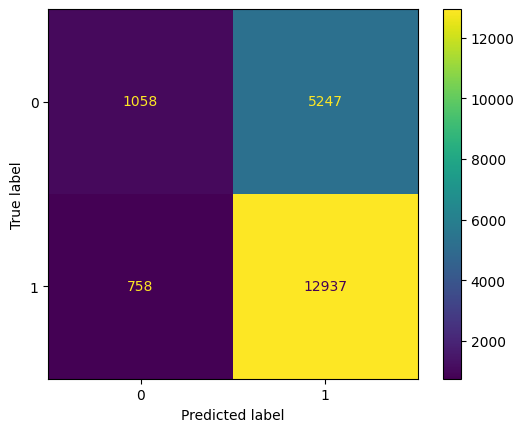

In [28]:
print(f"Classification Report: {classification_report(y_test, y_pred)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob)}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

**Hyperparameter Tuning**

In [14]:
# define a function for performing hyperparameter tuning
def perform_hyperparameter_tuning(param_grid:dict, X_train, y_train) -> None:
    """Performs RandomizedSearchCV Hyperparameter Tuning Technique"""

    with mlflow.start_run(run_name='Linear SVC Hyperparameter Tuning'):
        # set the tags
        mlflow.set_tags(
            {
                'experiment_type': 'Linear SVC Hyperparameter Tuning',
                'model_type': 'Linear SVC',
                'dataset_version': 'v1'
            }
        )

        cv = StratifiedKFold(n_splits=3)
    
        random_search = RandomizedSearchCV(svc_pipeline, param_distributions=param_grid, n_iter=15, cv=cv, scoring='roc_auc', random_state=42)

        # fit the data into the model
        random_search.fit(X_train, y_train)

        # fetch the best model
        best_model = random_search.best_estimator_

        # make predictions
        y_pred = best_model.predict(X_test)
        y_prob = best_model.decision_function(X_test)

        # evaluate the model
        metrics = evaluate_model(y_test, y_pred, y_prob)

        # log the test metrics
        mlflow.log_metrics(metrics)

        # log the mdoel parameters
        classifier_params = best_model.named_steps['classifier'].get_params()

        mlflow.log_params({
            'penalty': classifier_params['penalty'],
            'C': classifier_params['C'],
            'class_weight': classifier_params['class_weight'],
            'max_iter': classifier_params['max_iter']
        })

        # log the model
        mlflow.sklearn.log_model(
            best_model,
            "hyperparameter_tuned_svc_pipeline"
        )

        # store the dataset in artifacts folder
        df.to_csv("data.csv", index=False)
        mlflow.log_artifact("data.csv")

        # log the confusion matrix image in artifacts
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")
        plt.close()

    # display the best hyperparameters, best cv_score and
    print("Best Hyperparameters:", random_search.best_params_)
    print("Best ROC AUC Score:", random_search.best_score_)

    print(f"Classification Report: \n{classification_report(y_test, y_pred)}")
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob)}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

2026/05/14 20:50:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 20:50:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Linear SVC Hyperparameter Tuning at: https://dagshub.com/aditya-mahato-8924/Placement-Predictor.mlflow/#/experiments/3/runs/7a120de1995f4ba88e427be60cd500d2
🧪 View experiment at: https://dagshub.com/aditya-mahato-8924/Placement-Predictor.mlflow/#/experiments/3
Best Hyperparameters: {'classifier__penalty': 'l2', 'classifier__max_iter': 10000, 'classifier__class_weight': {0: 1.5, 1: 1}, 'classifier__C': 1}
Best ROC AUC Score: 0.6856431911416019
Classification Report: 
              precision    recall  f1-score   support

           0       0.49      0.43      0.46      6305
           1       0.75      0.80      0.77     13695

    accuracy                           0.68     20000
   macro avg       0.62      0.61      0.61     20000
weighted avg       0.67      0.68      0.67     20000

ROC AUC Score: 0.6855705946849905


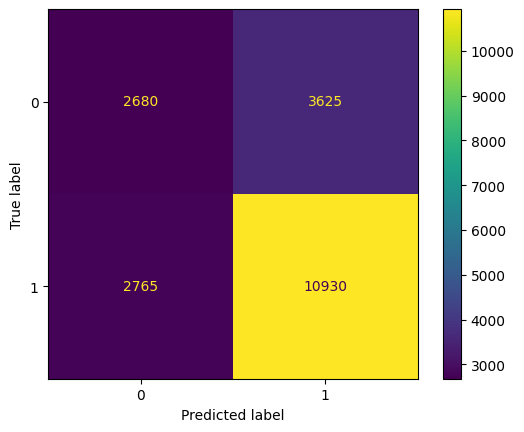

In [16]:
# perform hyperparameter tuning for linear svc

# define the parameter grid
param_grid = {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.5, 1, 10],
        'classifier__class_weight': [
            'balanced',
            {0:1.5, 1:1},
            {0:2, 1:1}
        ],
        'classifier__max_iter': [10000, 15000, 5000, 1000]
    }
perform_hyperparameter_tuning(param_grid, X_train, y_train)